# PolySHAP in `shapiq`: how `max_order` should track the game's interaction order

The earlier notebook (`polyshap_reproduction.ipynb`) reproduced the paper on
*real* explanation games, where the true interaction structure is unknown and
higher orders keep helping. This notebook asks a sharper, controlled question:

> If a game's interactions genuinely stop at order **k**, what is the *right*
> `max_order` to give `PolySHAPKAdd` — and what happens on either side of it?

To answer it cleanly we build games whose interaction order is **exactly known**:
synthetic **3-additive** games (`k = 3`). Their Möbius (interaction) representation
has non-zero terms only up to triples, so a degree-3 polynomial fit can represent
them *perfectly* while lower degrees cannot, and higher degrees add nothing.

Sweeping `PolySHAPKAdd(max_order=...)` against this known `k = 3` should show:

| `max_order` vs `k` | expected behaviour |
|---|---|
| `max_order = 1` (`< k`) | **reduces to KernelSHAP** |
| `max_order = 2` (`< k`) | **improves over KernelSHAP** |
| `max_order = 3` (`= k`) | **captures the game exactly** — best estimator |
| `max_order = 4` (`> k`) | **no further gain, and needs a much larger budget** |

We show the same behaviour across **three different non-trivial games** of growing
size. `shapiq`'s `KernelSHAP` is included as a blue baseline; `1-PolySHAP` (teal)
should sit right on top of it, confirming the reduction.

This is a *showcase*: small `N` and small games keep it laptop-friendly.

## 0 · Setup

Everything is self-contained — only `numpy`/`matplotlib` and the integrated
`shapiq` approximators are used. Figures are written to `plots/`.

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shapiq
from shapiq import ExactComputer
from shapiq.approximator import KernelSHAP
from shapiq.approximator.regression.polyshap import PolySHAPKAdd

HERE = Path.cwd()
NB_DIR = next((c for c in (HERE, HERE / "polyshap", HERE / "notebooks" / "polyshap")
               if (c / "build_maxorder_notebook.py").exists()), HERE)
PLOTS_DIR = NB_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    path = PLOTS_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

print("integrated shapiq:", shapiq.__file__)
print("plots ->", PLOTS_DIR)

integrated shapiq: C:\Users\Black\Documents\Studium\SoSe26\TTML Toolbox for Trustworthy Machine Learning\PROJECT\shapiq\src\shapiq\__init__.py
plots -> C:\Users\Black\Documents\Studium\SoSe26\TTML Toolbox for Trustworthy Machine Learning\PROJECT\shapiq\notebooks\polyshap\plots


## 1 · Colour scheme and legend

The same colour-per-order scheme as the reproduction notebook (teal → amber →
deep orange → dark red for orders 1–4), plus **`KernelSHAP` in blue** as the
explicit baseline.

In [2]:
COLORS = {
    "KernelSHAP": "#1f77b4",   # blue   — baseline
    "1-PolySHAP": "#009587",   # teal   (== KernelSHAP)
    "2-PolySHAP": "#ffb64d",   # amber
    "3-PolySHAP": "#e64918",   # deep orange  (= k, the true order)
    "4-PolySHAP": "#bf360b",   # dark red
}
# 1-PolySHAP overlaps KernelSHAP, so draw it dashed to keep both visible.
LINESTYLE = {"KernelSHAP": "-", "1-PolySHAP": "--",
             "2-PolySHAP": "-", "3-PolySHAP": "-", "4-PolySHAP": "-"}
MARKER = {"KernelSHAP": "o", "1-PolySHAP": "x",
          "2-PolySHAP": "s", "3-PolySHAP": "^", "4-PolySHAP": "D"}
METHODS = list(COLORS)
POLY_ORDER = {"1-PolySHAP": 1, "2-PolySHAP": 2, "3-PolySHAP": 3, "4-PolySHAP": 4}

## 2 · Three controlled 3-additive games (`k = 3`)

Each game is built directly from a **Möbius (interaction) representation** that
is non-zero only up to triples. The value of a coalition `S` is the sum of the
interaction coefficients of every subset `T ⊆ S` with `|T| ≤ 3`:

$$v(S) = \sum_{\substack{T \subseteq S \\ 1 \le |T| \le 3}} m(T).$$

By construction these games are **exactly 3-additive**, so `k = 3` is the true
interaction order. We use three games of growing size and different structure so
the conclusion is not an artefact of one game:

| Game | `n` | structure |
|---|---|---|
| `Dense-10`  | 10 | all singles/pairs/triples present |
| `Decay-12`  | 12 | coefficients shrink with order |
| `Sparse-14` | 14 | all singles/pairs, only 30% of triples |

Exact Shapley ground truth comes straight from `shapiq.ExactComputer` (the games
are small enough to enumerate).

In [3]:
from dataclasses import dataclass

@dataclass(frozen=True)
class GameSpec:
    name: str
    n: int
    p3: float     # probability a given triple is present
    decay: float  # per-order coefficient scale (order o has scale decay**(o-1))

GAME_SPECS = {
    "Dense-10":  GameSpec("Dense-10", 10, p3=1.0, decay=0.7),
    "Decay-12":  GameSpec("Decay-12", 12, p3=1.0, decay=0.5),
    "Sparse-14": GameSpec("Sparse-14", 14, p3=0.3, decay=0.8),
}
K = 3  # true interaction order of every game

def make_kadd_game(spec: GameSpec, seed: int):
    # Build one exactly-3-additive game callable: (m, n) bool -> (m,) values.
    rng = np.random.default_rng(seed)
    terms = []  # (indices array, coefficient)
    for order in range(1, K + 1):
        scale = spec.decay ** (order - 1)
        for T in combinations(range(spec.n), order):
            if order < 3 or rng.random() < spec.p3:
                terms.append((np.asarray(T), rng.normal(0.0, scale)))

    def game(X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=bool)
        out = np.zeros(len(X))
        for idx, coef in terms:
            out += coef * X[:, idx].all(axis=1)  # T contributes iff T ⊆ S
        return out

    return game

def exact_shapley(game, n: int) -> np.ndarray:
    sv = ExactComputer(game, n_players=n)(index="SV", order=1)
    return np.asarray(sv.get_n_order_values(1), dtype=float)

## 3 · Estimators and the budget sweep

`PolySHAPKAdd(max_order=k)` needs at least `n_variables` coalition evaluations
(one per frontier term: `1 + C(n,1) + … + C(n,k)`). Below that budget the fit is
under-determined, so we skip it — and this is precisely the cost of going to a
higher order: a degree-4 frontier only becomes affordable far to the right.

For each game we average over `N_INSTANCES = 3` random instances (kept small so
the showcase runs quickly) and sweep the budget log-spaced from `n+1` up to full
enumeration `2**n`.

In [4]:
N_INSTANCES = 3   # instances averaged per game (small = fast; it's a showcase)
SEED = 40
N_BUDGET_STEPS = 14
MSE_FLOOR = 1e-12  # log-axis floor; exact (k>=3) fits land here

def budget_grid(n: int) -> list[int]:
    lo, hi = n + 1, 2 ** n
    grid = np.unique(np.round(np.logspace(np.log10(lo), np.log10(hi), N_BUDGET_STEPS)).astype(int))
    return sorted(int(b) for b in grid)

def make_method(name: str, n: int, random_state: int):
    weights = np.ones(n + 1)  # uniform over subset sizes (order-1 leverage scores)
    if name == "KernelSHAP":
        return KernelSHAP(n=n, sampling_weights=weights, random_state=random_state)
    return PolySHAPKAdd(n=n, max_order=POLY_ORDER[name], sampling_weights=weights,
                        random_state=random_state)

def n_variables(name: str, n: int) -> int:
    return make_method(name, n, 0).n_variables

def run_sweep() -> pd.DataFrame:
    rows = []
    for gname, spec in GAME_SPECS.items():
        budgets = budget_grid(spec.n)
        for inst in range(1, N_INSTANCES + 1):
            game = make_kadd_game(spec, seed=SEED + inst)
            exact = exact_shapley(game, spec.n)
            for budget in budgets:
                for name in METHODS:
                    est_obj = make_method(name, spec.n, SEED + inst)
                    if getattr(est_obj, "n_variables", 0) > budget:
                        continue  # frontier needs a bigger budget than we have
                    iv = est_obj.approximate(budget=budget, game=game)
                    est = np.asarray(iv.get_n_order_values(1), dtype=float)
                    rows.append({"game": gname, "n": spec.n, "instance": inst,
                                 "budget": budget, "method": name,
                                 "MSE": float(np.mean((est - exact) ** 2))})
    return pd.DataFrame(rows)

df = run_sweep()
print(f"{len(df)} (game, instance, budget, method) cells computed")
df.head()

C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 9 sampled coalition(s) but 10 frontier variable(s). Increase the budget (currently 11) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 9 sampled coalition(s) but 10 frontier variable(s). Increase the budget (currently 11) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 9 sampled coalition(s) but 10 frontier variable(s). Increase the budget (currently 11) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 11 sampled coalition(s) but 12 frontier variable(s). Increase the budget (currently 13) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 11 sampled coalition(s) but 12 frontier variable(s). Increase the budget (currently 13) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


...

C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 13 sampled coalition(s) but 14 frontier variable(s). Increase the budget (currently 15) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 13 sampled coalition(s) but 14 frontier variable(s). Increase the budget (currently 15) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


C:\Users\Black\AppData\Local\Temp\ipykernel_26156\3052897680.py:33: UserWarning: The least-squares system is underdefined: 13 sampled coalition(s) but 14 frontier variable(s). Increase the budget (currently 15) or reduce the explanation frontier size for reliable estimates.
  iv = est_obj.approximate(budget=budget, game=game)


429 (game, instance, budget, method) cells computed


,game,n,instance,budget,method,MSE
0,Dense-10,10,1,11,KernelSHAP,36.951396
1,Dense-10,10,1,11,1-PolySHAP,5.849629
2,Dense-10,10,1,16,KernelSHAP,1.548615
3,Dense-10,10,1,16,1-PolySHAP,1.548615
4,Dense-10,10,1,22,KernelSHAP,1.083570


## 4 · The figure

One panel per game, log–log axes (budget vs. MSE), mean ± SEM across the
`N_INSTANCES` instances. Dotted vertical guides mark the budgets at which the
degree-3 and degree-4 frontiers *first become affordable* (`n_variables`) — note
how far right the degree-4 guide sits for no accuracy benefit.

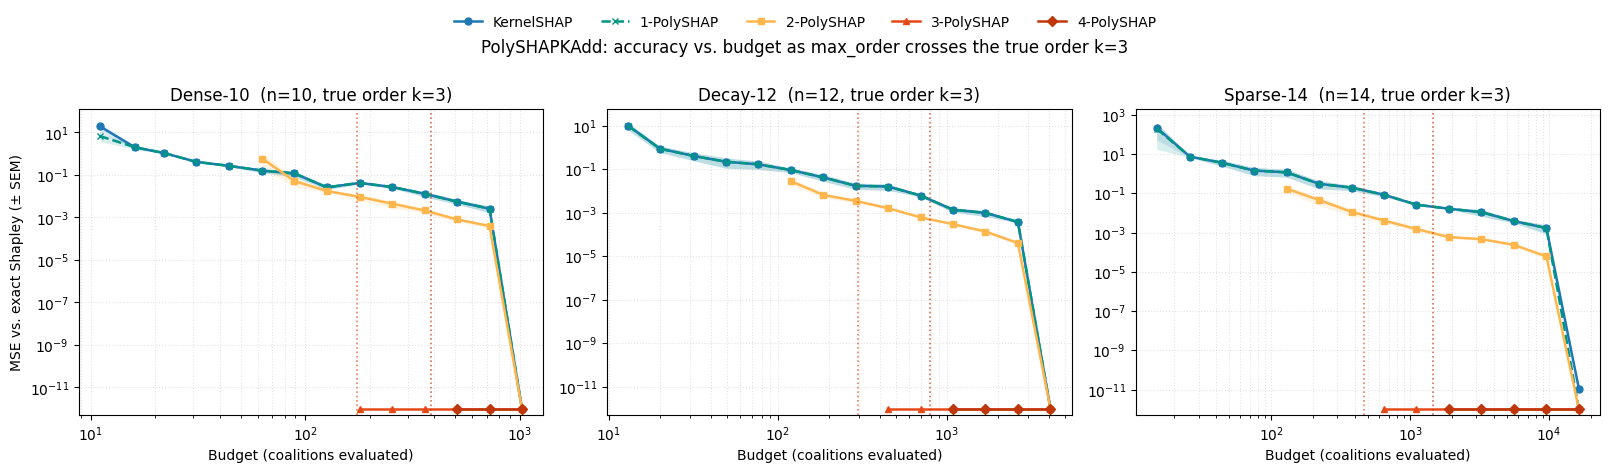

In [5]:
def agg(df):
    g = df.groupby(["game", "method", "budget"])["MSE"]
    return g.agg(["mean", "sem"]).reset_index()

def panel(ax, A, spec):
    sub = A[A["game"] == spec.name]
    for name in METHODS:
        s = sub[sub["method"] == name].sort_values("budget")
        if s.empty:
            continue
        mean = np.maximum(s["mean"].to_numpy(), MSE_FLOOR)
        sem = np.nan_to_num(s["sem"].to_numpy())
        lo = np.maximum(mean - sem, MSE_FLOOR)
        hi = mean + sem
        ax.plot(s["budget"], mean, ls=LINESTYLE[name], marker=MARKER[name], ms=5,
                lw=1.8, color=COLORS[name], label=name)
        ax.fill_between(s["budget"], lo, hi, color=COLORS[name], alpha=0.15, lw=0)
    # budget at which the k=3 / k=4 frontiers first become affordable
    for name, c in (("3-PolySHAP", COLORS["3-PolySHAP"]), ("4-PolySHAP", COLORS["4-PolySHAP"])):
        ax.axvline(n_variables(name, spec.n), color=c, ls=":", lw=1.2, alpha=0.7)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylim(MSE_FLOOR * 0.5, None)
    ax.set_xlabel("Budget (coalitions evaluated)")
    ax.set_title(f"{spec.name}  (n={spec.n}, true order k={K})")
    ax.grid(True, which="both", ls=":", alpha=0.35)

A = agg(df)
fig, axes = plt.subplots(1, len(GAME_SPECS), figsize=(5.4 * len(GAME_SPECS), 4.4),
                         squeeze=False)
for ax, spec in zip(axes[0], GAME_SPECS.values()):
    panel(ax, A, spec)
axes[0][0].set_ylabel("MSE vs. exact Shapley (± SEM)")
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(METHODS),
           bbox_to_anchor=(0.5, 1.08), frameon=False)
fig.suptitle("PolySHAPKAdd: accuracy vs. budget as max_order crosses the true order k=3",
             y=1.00, fontsize=12)
fig.tight_layout()
save_fig(fig, "maxorder_vs_k.png")
plt.show()

### Reading the figure

* **`max_order = 1` reduces to KernelSHAP.** The teal dashed `1-PolySHAP` curve
  lies on top of the blue `KernelSHAP` baseline — they are the same estimator.
* **`max_order = 2` improves over KernelSHAP.** Amber sits clearly below blue/teal
  at every budget: one extra interaction order already buys accuracy.
* **`max_order = 3` (`= k`) captures the game exactly.** Once the budget reaches
  the degree-3 frontier size (left dotted guide), deep-orange drops to the MSE
  floor — the 3-additive game is represented perfectly.
* **`max_order = 4` (`> k`) gives no gain at a higher cost.** Dark red only
  appears at the right dotted guide (a much larger budget) and then merely matches
  degree-3. The extra order is pure overhead: it does **not** beat `max_order = 3`,
  it only postpones the point at which the estimator becomes affordable.

## 5 · The ordering, numerically

At a budget where **all** orders are affordable (the degree-4 frontier size, the
right dotted guide), mean MSE should fall as `1-PolySHAP ≈ KernelSHAP > 2-PolySHAP
> 3-PolySHAP ≈ 4-PolySHAP`, with degree-3 already at the floor and degree-4 no
better.

In [6]:
def table_at_budget():
    out = {}
    for gname, spec in GAME_SPECS.items():
        ref = min(b for b in budget_grid(spec.n) if b >= n_variables("4-PolySHAP", spec.n))
        sub = df[(df["game"] == gname) & (df["budget"] == ref)]
        out[f"{gname} (m={ref})"] = sub.groupby("method")["MSE"].mean()
    return pd.DataFrame(out).reindex(METHODS)

with pd.option_context("display.float_format", lambda v: f"{v:.2e}"):
    print(table_at_budget())
table_at_budget()

            Dense-10 (m=510)  Decay-12 (m=1086)  Sparse-14 (m=1903)
method                                                             
KernelSHAP          5.58e-03           1.39e-03            1.63e-02
1-PolySHAP          5.58e-03           1.39e-03            1.63e-02
2-PolySHAP          8.09e-04           3.01e-04            5.85e-04
3-PolySHAP          2.31e-27           1.82e-28            7.63e-28
4-PolySHAP          3.22e-26           5.87e-27            5.37e-25


,Dense-10 (m=510),Decay-12 (m=1086),Sparse-14 (m=1903)
method,,,
KernelSHAP,5.583816e-03,1.391943e-03,1.625890e-02
1-PolySHAP,5.583820e-03,1.391944e-03,1.625894e-02
2-PolySHAP,8.093536e-04,3.008957e-04,5.848692e-04
3-PolySHAP,2.307402e-27,1.817143e-28,7.632076e-28
4-PolySHAP,3.220290e-26,5.873261e-27,5.368482e-25


## Conclusion

Across three controlled 3-additive games, the integrated `PolySHAPKAdd` behaves
exactly as the interaction order predicts:

* `max_order < k` **under-fits** — degree 1 *is* KernelSHAP, degree 2 improves on it.
* `max_order = k` is the **sweet spot** — the game is captured exactly.
* `max_order > k` is **wasted budget** — no accuracy gain, only a higher minimum
  cost before the estimator can be fit at all.

The practical takeaway: choosing `max_order` is a bias/budget trade-off, and the
right target is the game's intrinsic interaction order. Pushing past it buys
nothing but cost. (When the order is *unknown*, as for the real games in
`polyshap_reproduction.ipynb`, higher orders keep helping precisely because those
games are not low-order.)